## Python Visualization Libraries

In this notebook, we will explore and compare different Python visualization libraries using the `mn-budget-detail-2014.csv` dataset (Minnesota (MN)). We'll create bar plots with each library to demonstrate their unique features and capabilities.

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource
from bokeh.palettes import Spectral10
import folium
import pygal

In [13]:
budget = pd.read_csv("./mn-budget-detail-2014.csv")
budget = budget.sort_values('amount', ascending=False)[:10]

In [14]:
budget.head()

,category,detail,amount
46,ADMINISTRATION,Capitol Renovation and Restoration Continued,126300000
1,UNIVERSITY OF MINNESOTA,Minneapolis; Tate Laboratory Renovation,56700000
78,HUMAN SERVICES,Minnesota Security Hospital - St. Peter,56317000
0,UNIVERSITY OF MINNESOTA,Higher Education Asset Preservation (HEAPR) 1,42500000
5,MINNESOTA STATE COLLEGES AND UNIVERSITIES,Higher Education Asset Preservation (HEAPR) 2,42500000


## 1. Matplotlib

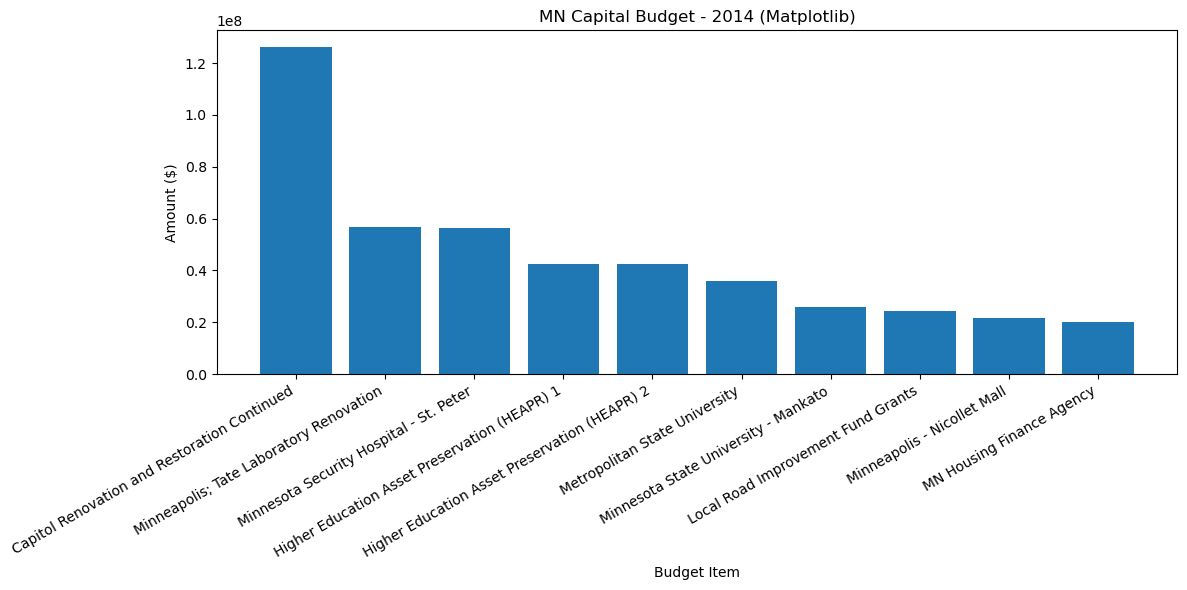

In [15]:
plt.figure(figsize=(12, 6))
plt.bar(budget['detail'], budget['amount'])
plt.title("MN Capital Budget - 2014 (Matplotlib)")
plt.xlabel("Budget Item")
plt.ylabel("Amount ($)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 2. Pandas

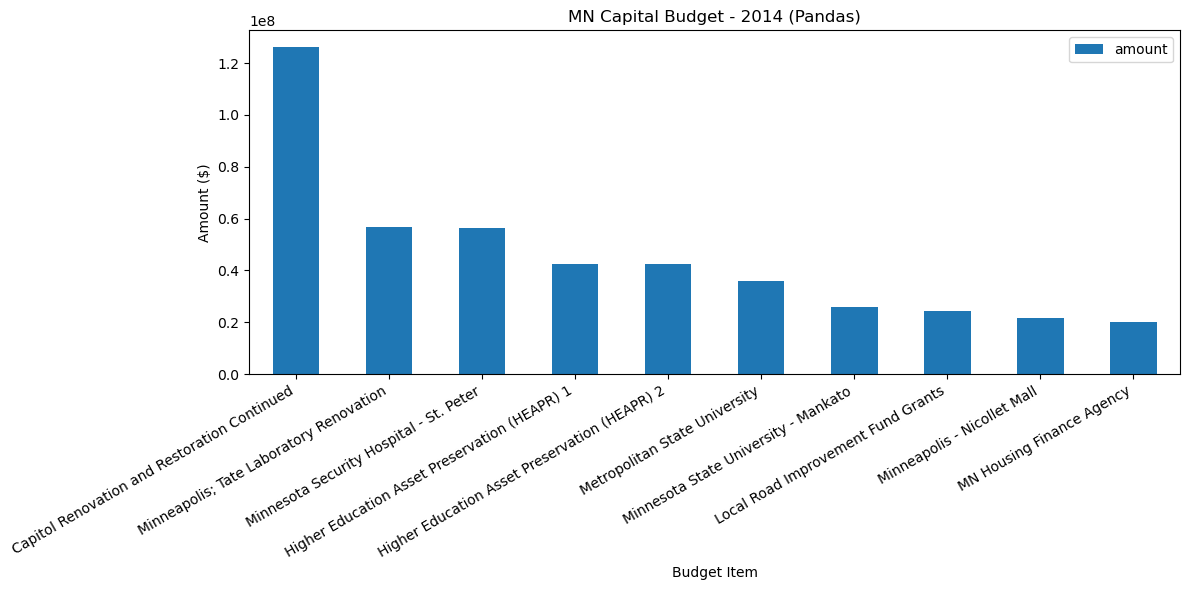

In [16]:
budget.plot(kind="bar", x="detail", y="amount", figsize=(12, 6))
plt.title("MN Capital Budget - 2014 (Pandas)")
plt.xlabel("Budget Item")
plt.ylabel("Amount ($)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 3. Seaborn

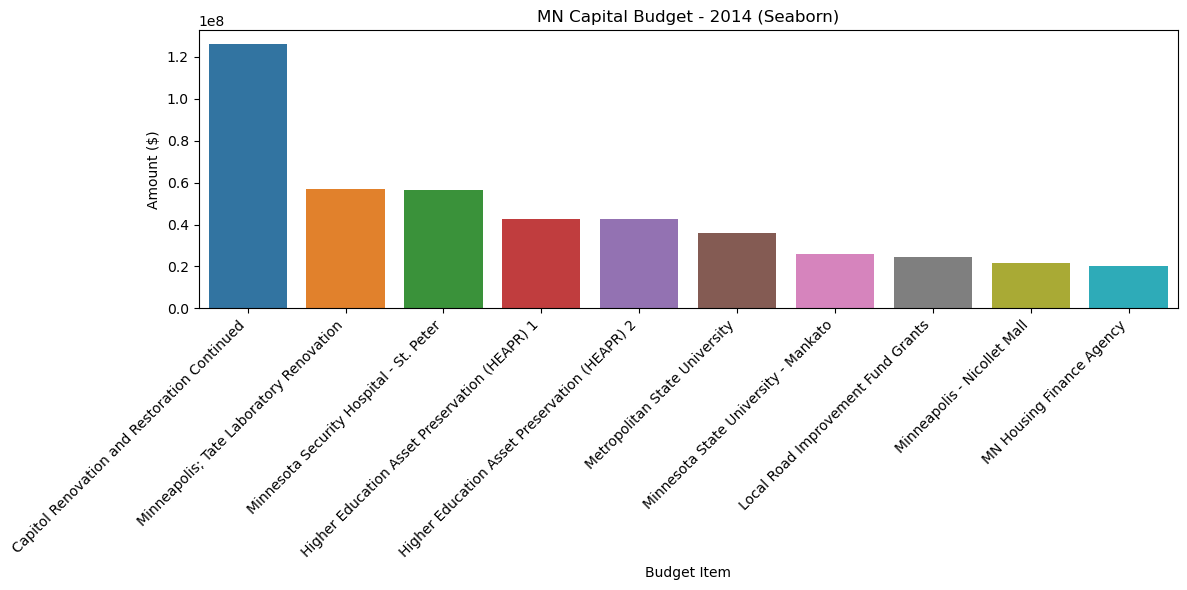

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(x="detail", y="amount", data=budget)
plt.title("MN Capital Budget - 2014 (Seaborn)")
plt.xlabel("Budget Item")
plt.ylabel("Amount ($)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Plotly

In [18]:
fig = px.bar(budget, x="detail", y="amount", title="MN Capital Budget - 2014 (Plotly)")
fig.update_layout(xaxis_title="Budget Item", yaxis_title="Amount ($)")
fig.update_xaxes(tickangle=-30)
fig.show()

## 5. Bokeh

In [19]:
source = ColumnDataSource(budget)
p = figure(x_range=budget['detail'],  title="MN Capital Budget - 2014 (Bokeh)",
           toolbar_location=None, tools="")
p.vbar(x='detail', top='amount', width=0.9, source=source, line_color='white',
       fill_color=Spectral10[0])
p.xgrid.grid_line_color = None
p.y_range.start = 0
p.xaxis.axis_label = 'Budget Item'
p.yaxis.axis_label = 'Amount ($)'
p.xaxis.major_label_orientation = 0.7
show(p)

## 6. Folium (Map visualization)

In [20]:
m = folium.Map(location=[30.7296, 70], zoom_start=6)
folium.Marker(
    [44.9537, -93.0900],
    popup="Capitol Renovation: $126,300,000",
    tooltip="Largest Budget Item"
).add_to(m)
m

In [6]:
m.save("folium_map.html")

## Pygal

In [ ]:
# Create a Pygal Bar Chart
bar_chart = pygal.Bar(
    title='MN Capital Budget - 2014',
    x_label_rotation=45,
    truncate_label=20,
    show_legend=False,
    width=1000,
    height=500
)

# Add data to the chart
bar_chart.x_labels = budget['detail'].tolist()
bar_chart.add('Amount', budget['amount'].tolist())

bar_chart.render_to_file('mn_budget_2014_pygal.svg')

---